In [28]:
!pip install nibabel nilearn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 34.0 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt

In [3]:
def show_volume_slices(vol, title_prefix="", num_slices_per_axis=3, modality_idx=0):
    """
    vol: torch.Tensor, shape (C, D, H, W)
    modality_idx: which channel to display
    """
    vol = vol[modality_idx]  # (D, H, W)
    vol = vol.cpu().numpy()

    D, H, W = vol.shape

    # Middle indices
    z_mid = D // 2
    y_mid = H // 2
    x_mid = W // 2

    # Choose slice offsets around the middle
    offsets = list(range(-num_slices_per_axis // 2 + 1, num_slices_per_axis // 2 + 1))
    z_slices = [z_mid + o for o in offsets if 0 <= z_mid + o < D]
    y_slices = [y_mid + o for o in offsets if 0 <= y_mid + o < H]
    x_slices = [x_mid + o for o in offsets if 0 <= x_mid + o < W]

    fig, axes = plt.subplots(3, max(len(z_slices), len(y_slices), len(x_slices)),
                             figsize=(3 * num_slices_per_axis, 9))

    if axes.ndim == 1:  # if only one column
        axes = axes[None, :]

    # Row 0: axial (z) slices
    for i, z in enumerate(z_slices):
        ax = axes[0, i]
        ax.imshow(vol[z, :, :], cmap="gray")
        ax.set_title(f"Axial z={z}")
        ax.axis("off")

    # Row 1: coronal (y) slices
    for i, y in enumerate(y_slices):
        ax = axes[1, i]
        ax.imshow(vol[:, y, :], cmap="gray")
        ax.set_title(f"Coronal y={y}")
        ax.axis("off")

    # Row 2: sagittal (x) slices
    for i, x in enumerate(x_slices):
        ax = axes[2, i]
        ax.imshow(vol[:, :, x], cmap="gray")
        ax.set_title(f"Sagittal x={x}")
        ax.axis("off")

    fig.suptitle(title_prefix, fontsize=14)
    plt.tight_layout()
    plt.show()

In [19]:
import os
import glob
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset

class BraTSMultiModalNiiDataset(Dataset):
    """
    Expects a folder structure:

    exports/
        flair/
            1_BraTS2021_00529_flair.nii.gz
            ...
        t1/
            1_BraTS2021_00529_t1.nii.gz
            ...
        t1ce/
            1_BraTS2021_00529_t1ce.nii.gz
            ...
        t2/
            1_BraTS2021_00529_t2.nii.gz
            ...
        seg/
            1_BraTS2021_00529_seg.nii.gz
            ...

    Returns:
        image: np.ndarray of shape (C=4, H, W, D) for flair, t1, t1ce, t2
        seg:   np.ndarray of shape (H, W, D)
        case_id: str
    """

    def __init__(self, root_dir: str):
        self.root_dir = root_dir
        self.modalities = ["flair", "t1", "t1ce", "t2", "seg"]

        # Collect flair files and derive case IDs from them
        flair_pattern = os.path.join(root_dir, "flair", "*.nii.gz")
        self.samples = []

        for flair_path in sorted(glob.glob(flair_pattern)):
            fname = os.path.basename(flair_path)

            # strip suffix "_flair.nii.gz" → case prefix, e.g. "1_BraTS2021_00529"
            if not fname.endswith("_flair.nii.gz"):
                continue
            case_id = fname.replace("_flair.nii.gz", "")

            # construct paths for all modalities
            paths = {}
            for mod in self.modalities:
                suffix = f"_{mod}.nii.gz"
                mod_path = os.path.join(
                    root_dir, mod, case_id + suffix
                )
                if not os.path.exists(mod_path):
                    raise FileNotFoundError(f"Missing modality {mod} for case {case_id}")
                paths[mod] = mod_path

            self.samples.append({"case_id": case_id, "paths": paths})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        paths = sample["paths"]

        vols = []
        for p in paths.values():
            img = nib.load(str(p))
            vol = img.get_fdata().astype(np.float32)

            # Expect shape (H, W, D) -> reorder to (D, H, W)
            if vol.ndim == 4:
                # just in case, drop singleton
                vol = vol[..., 0]
            vol = np.transpose(vol, (2, 0, 1))  # (D, H, W)

            #vol = _normalize_volume(vol)
            vols.append(vol)

        vol = np.stack(vols, axis=0)  # (C=4, D, H, W)
        vol = torch.from_numpy(vol).float()  # (4, D, H, W)
        return vol#, seg, sample["case_id"]

Dataset length: 2
Case 0: shape (5, 155, 240, 240) (C, D, H, W)
tensor(0.)


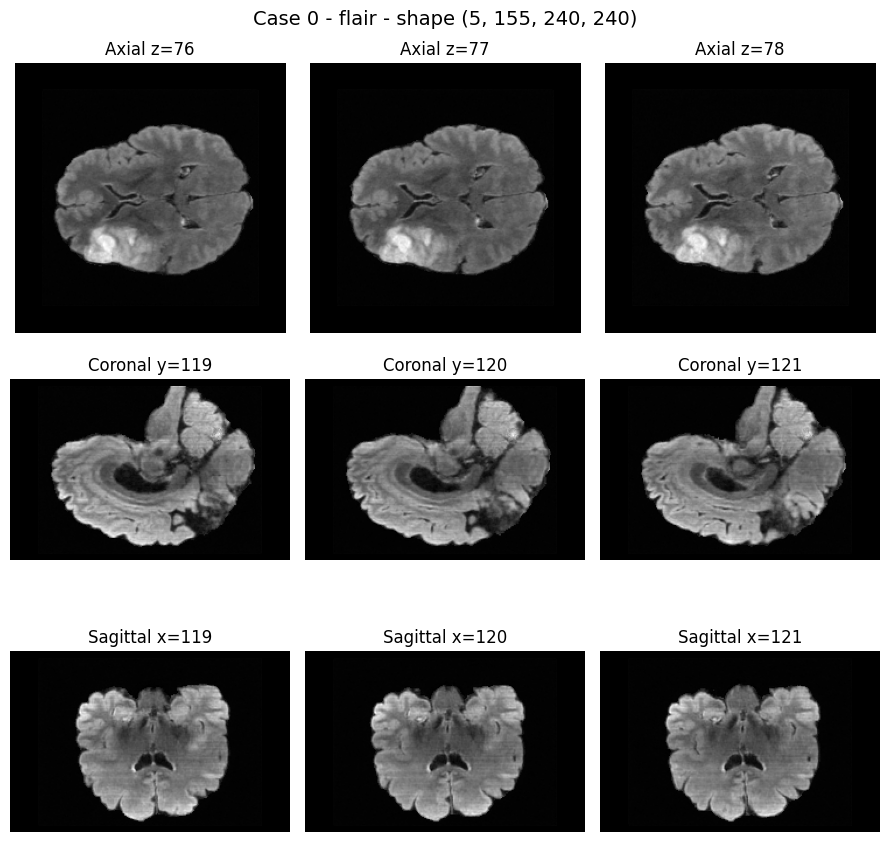

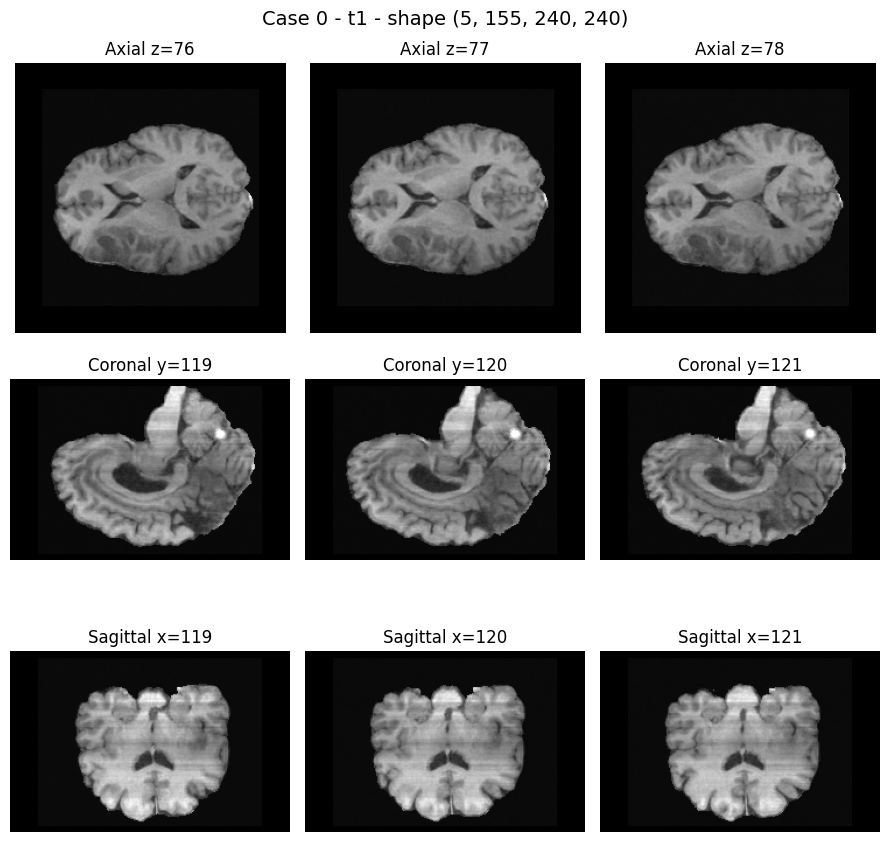

Case 1: shape (5, 155, 240, 240) (C, D, H, W)
tensor(0.)


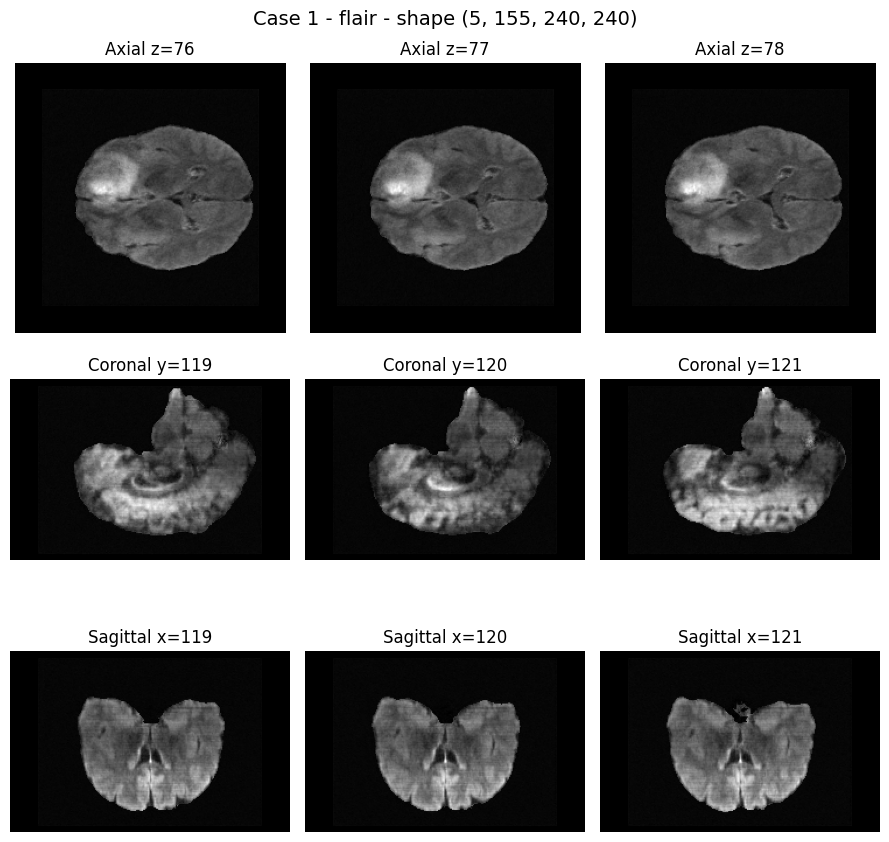

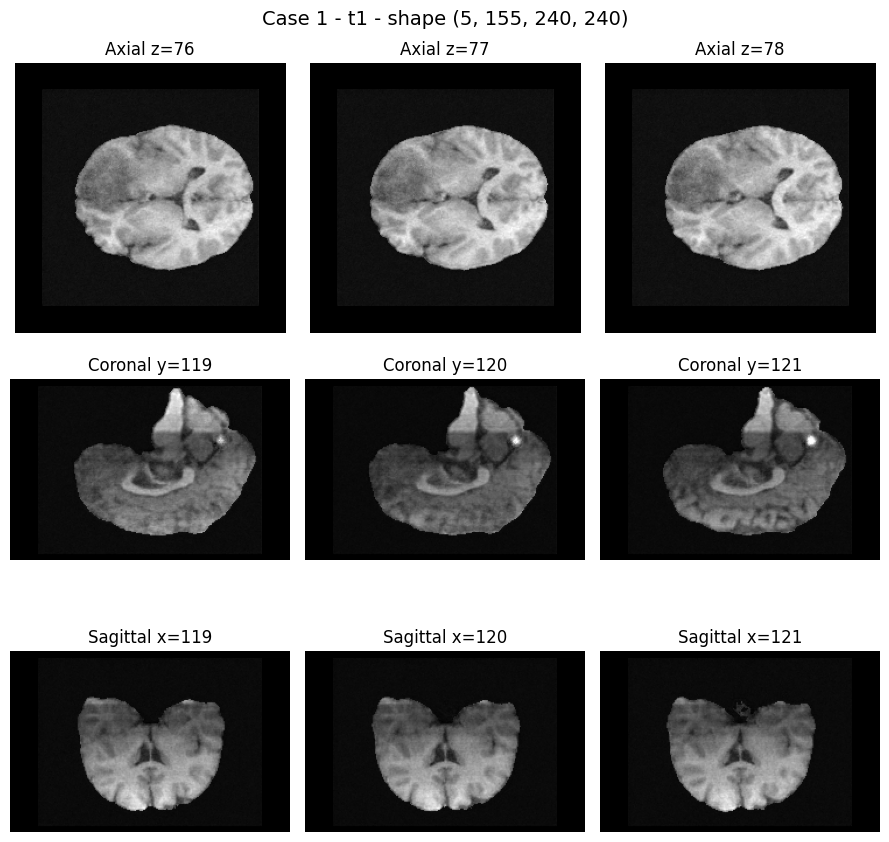

In [25]:
from experiments.lddpm_3d.dataset import create_dataset

num_cases = 3
modalities=("flair", "t1")

#dataset = create_dataset(
#    root=Path("data/brats-2021"),
#    patch_size=None,
#    max_cases=num_cases,
#    modalities=modalities,
#)

dataset = BraTSMultiModalNiiDataset("experiments/med-ddpm/exports")

print(f"Dataset length: {len(dataset)}")

for i in range(min(num_cases, len(dataset))):
    vol = dataset[i]  # (C, D, H, W)
    print(f"Case {i}: shape {tuple(vol.shape)} (C, D, H, W)")

    print(vol[0, 0, :, :].sum())
    for j, modality in enumerate(modalities):
        show_volume_slices(
            vol,
            title_prefix=f"Case {i} - {modality} - shape {tuple(vol.shape)}",
            num_slices_per_axis=3,
            modality_idx=j,
        )


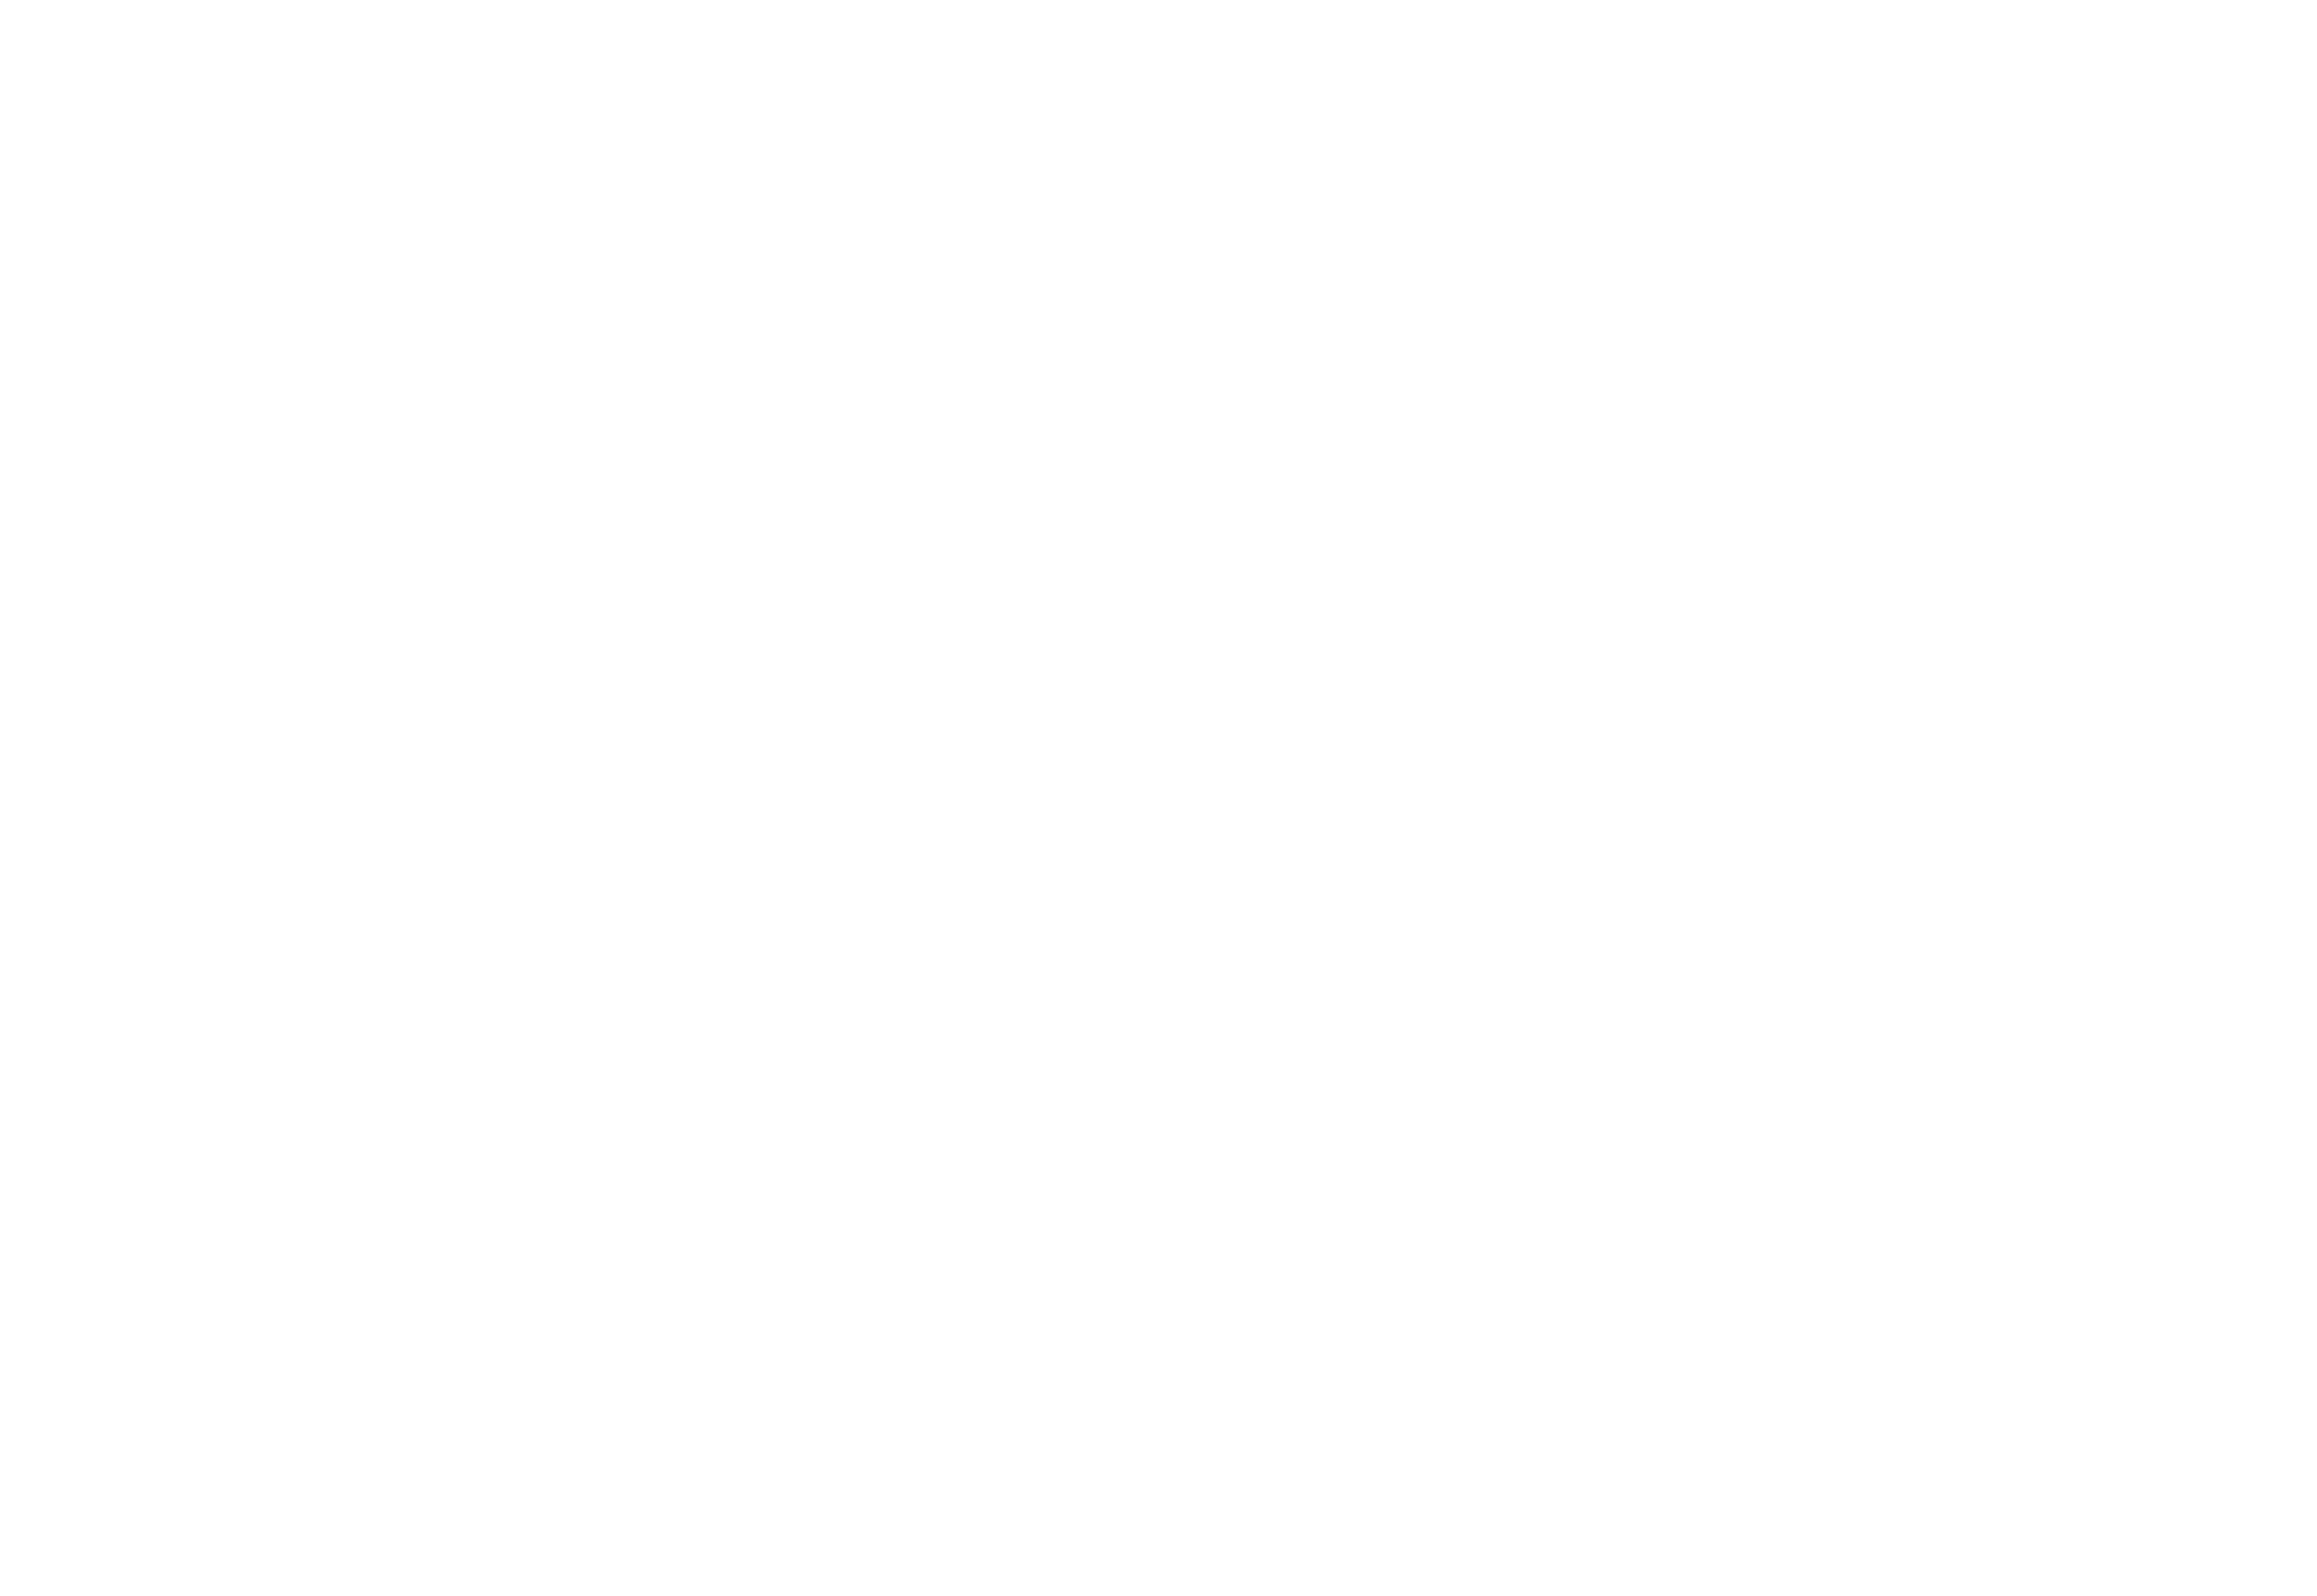
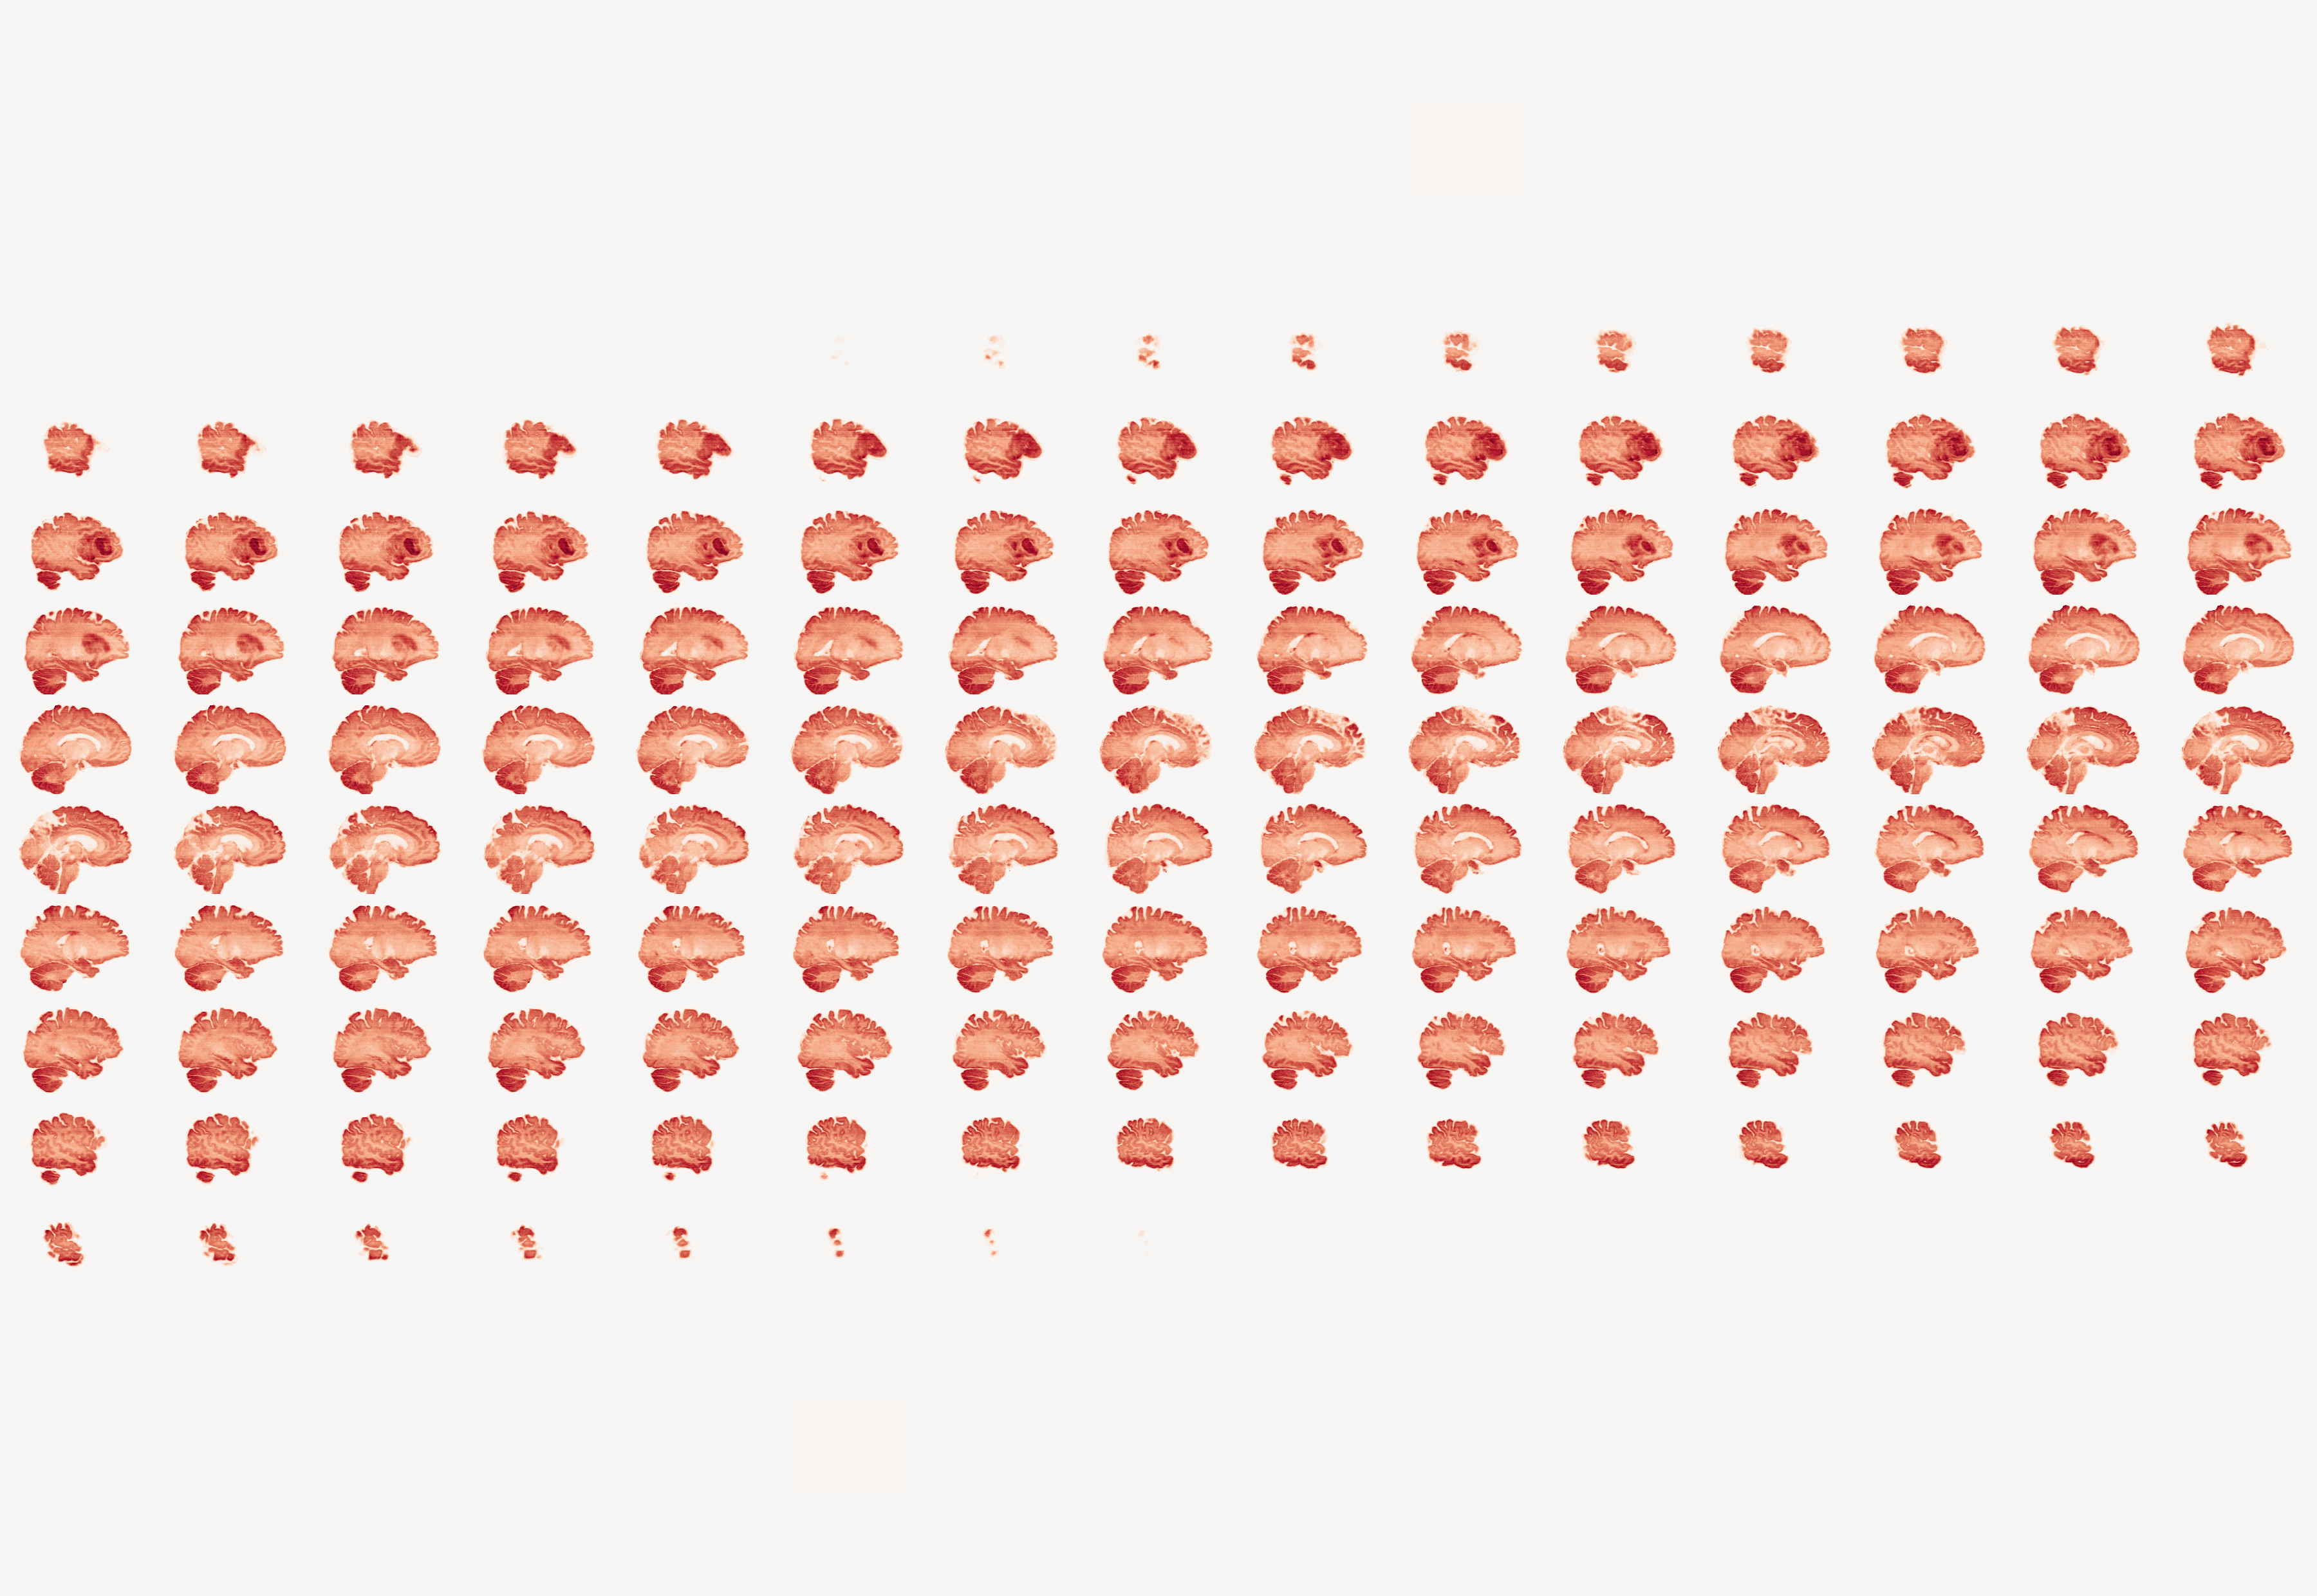

In [32]:
from nilearn import plotting

img = nib.load("experiments/med-ddpm/exports/flair/1_BraTS2021_00529_flair.nii.gz")

view = plotting.view_img(img, bg_img=None, threshold=None)
view

/scratch/slurm_tmpdir/job_1599632/ipykernel_1956538/4167179779.py:5: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  view = plotting.view_img(seg, bg_img=None, threshold=None)



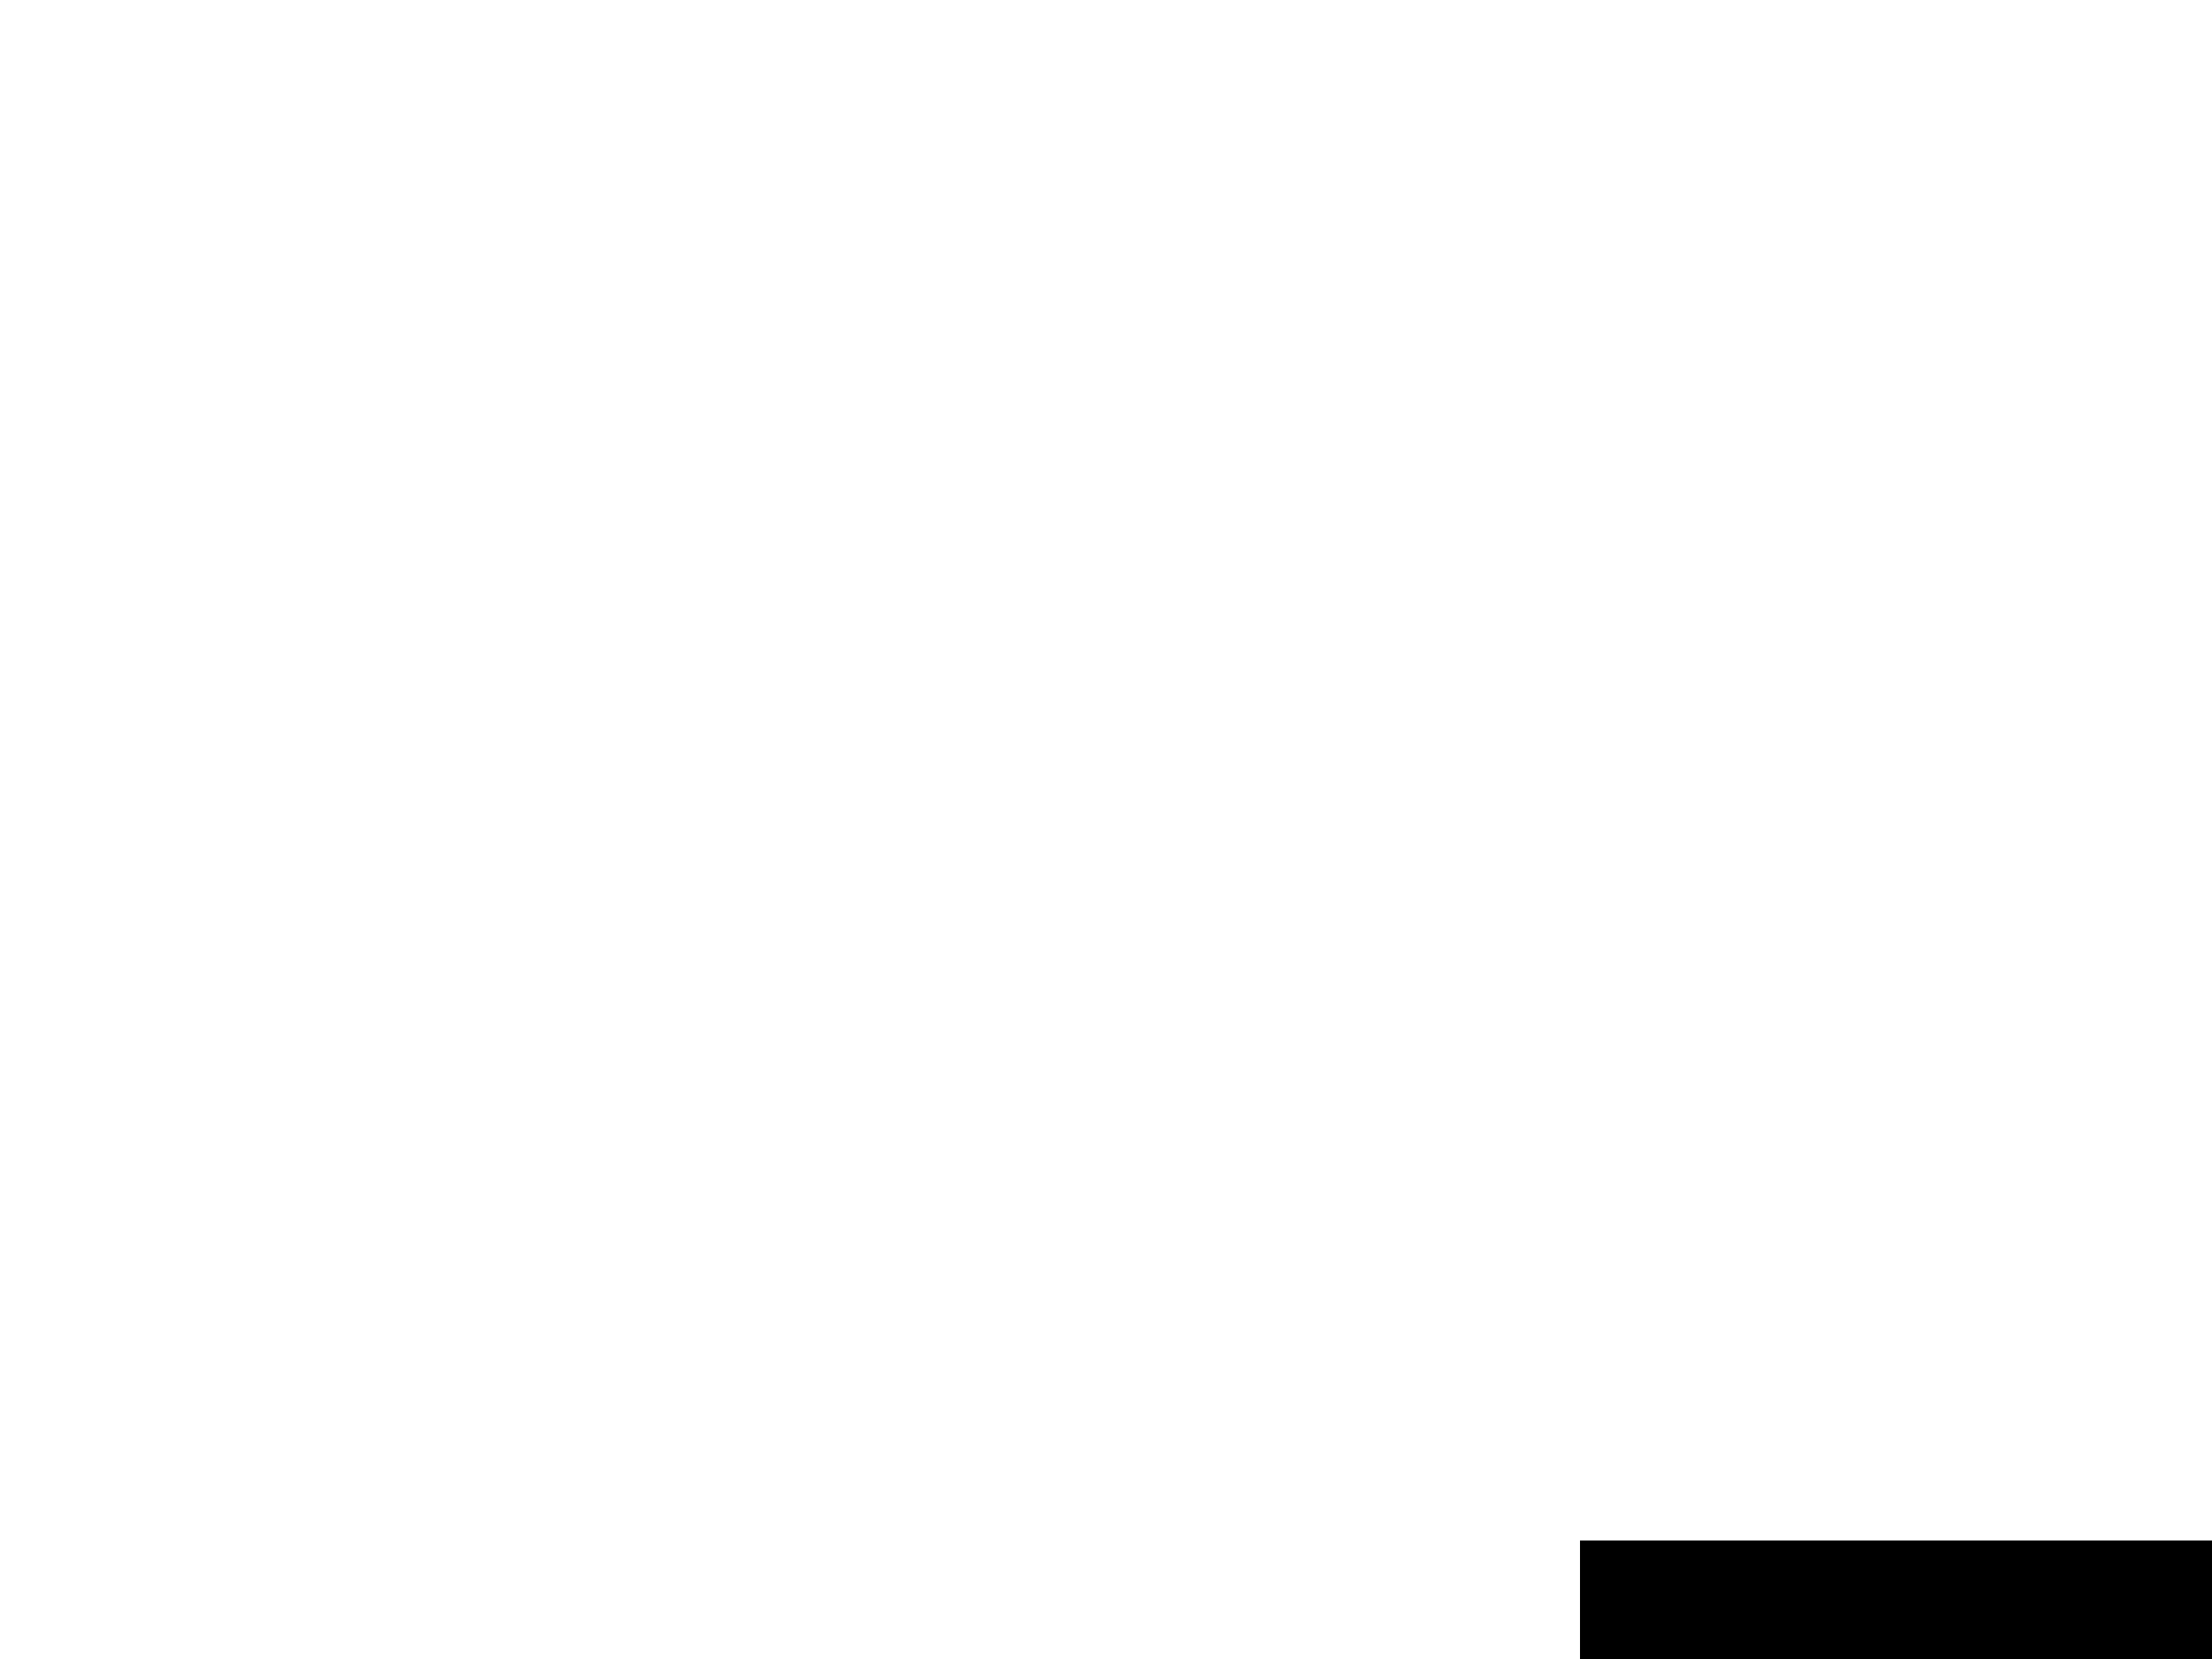
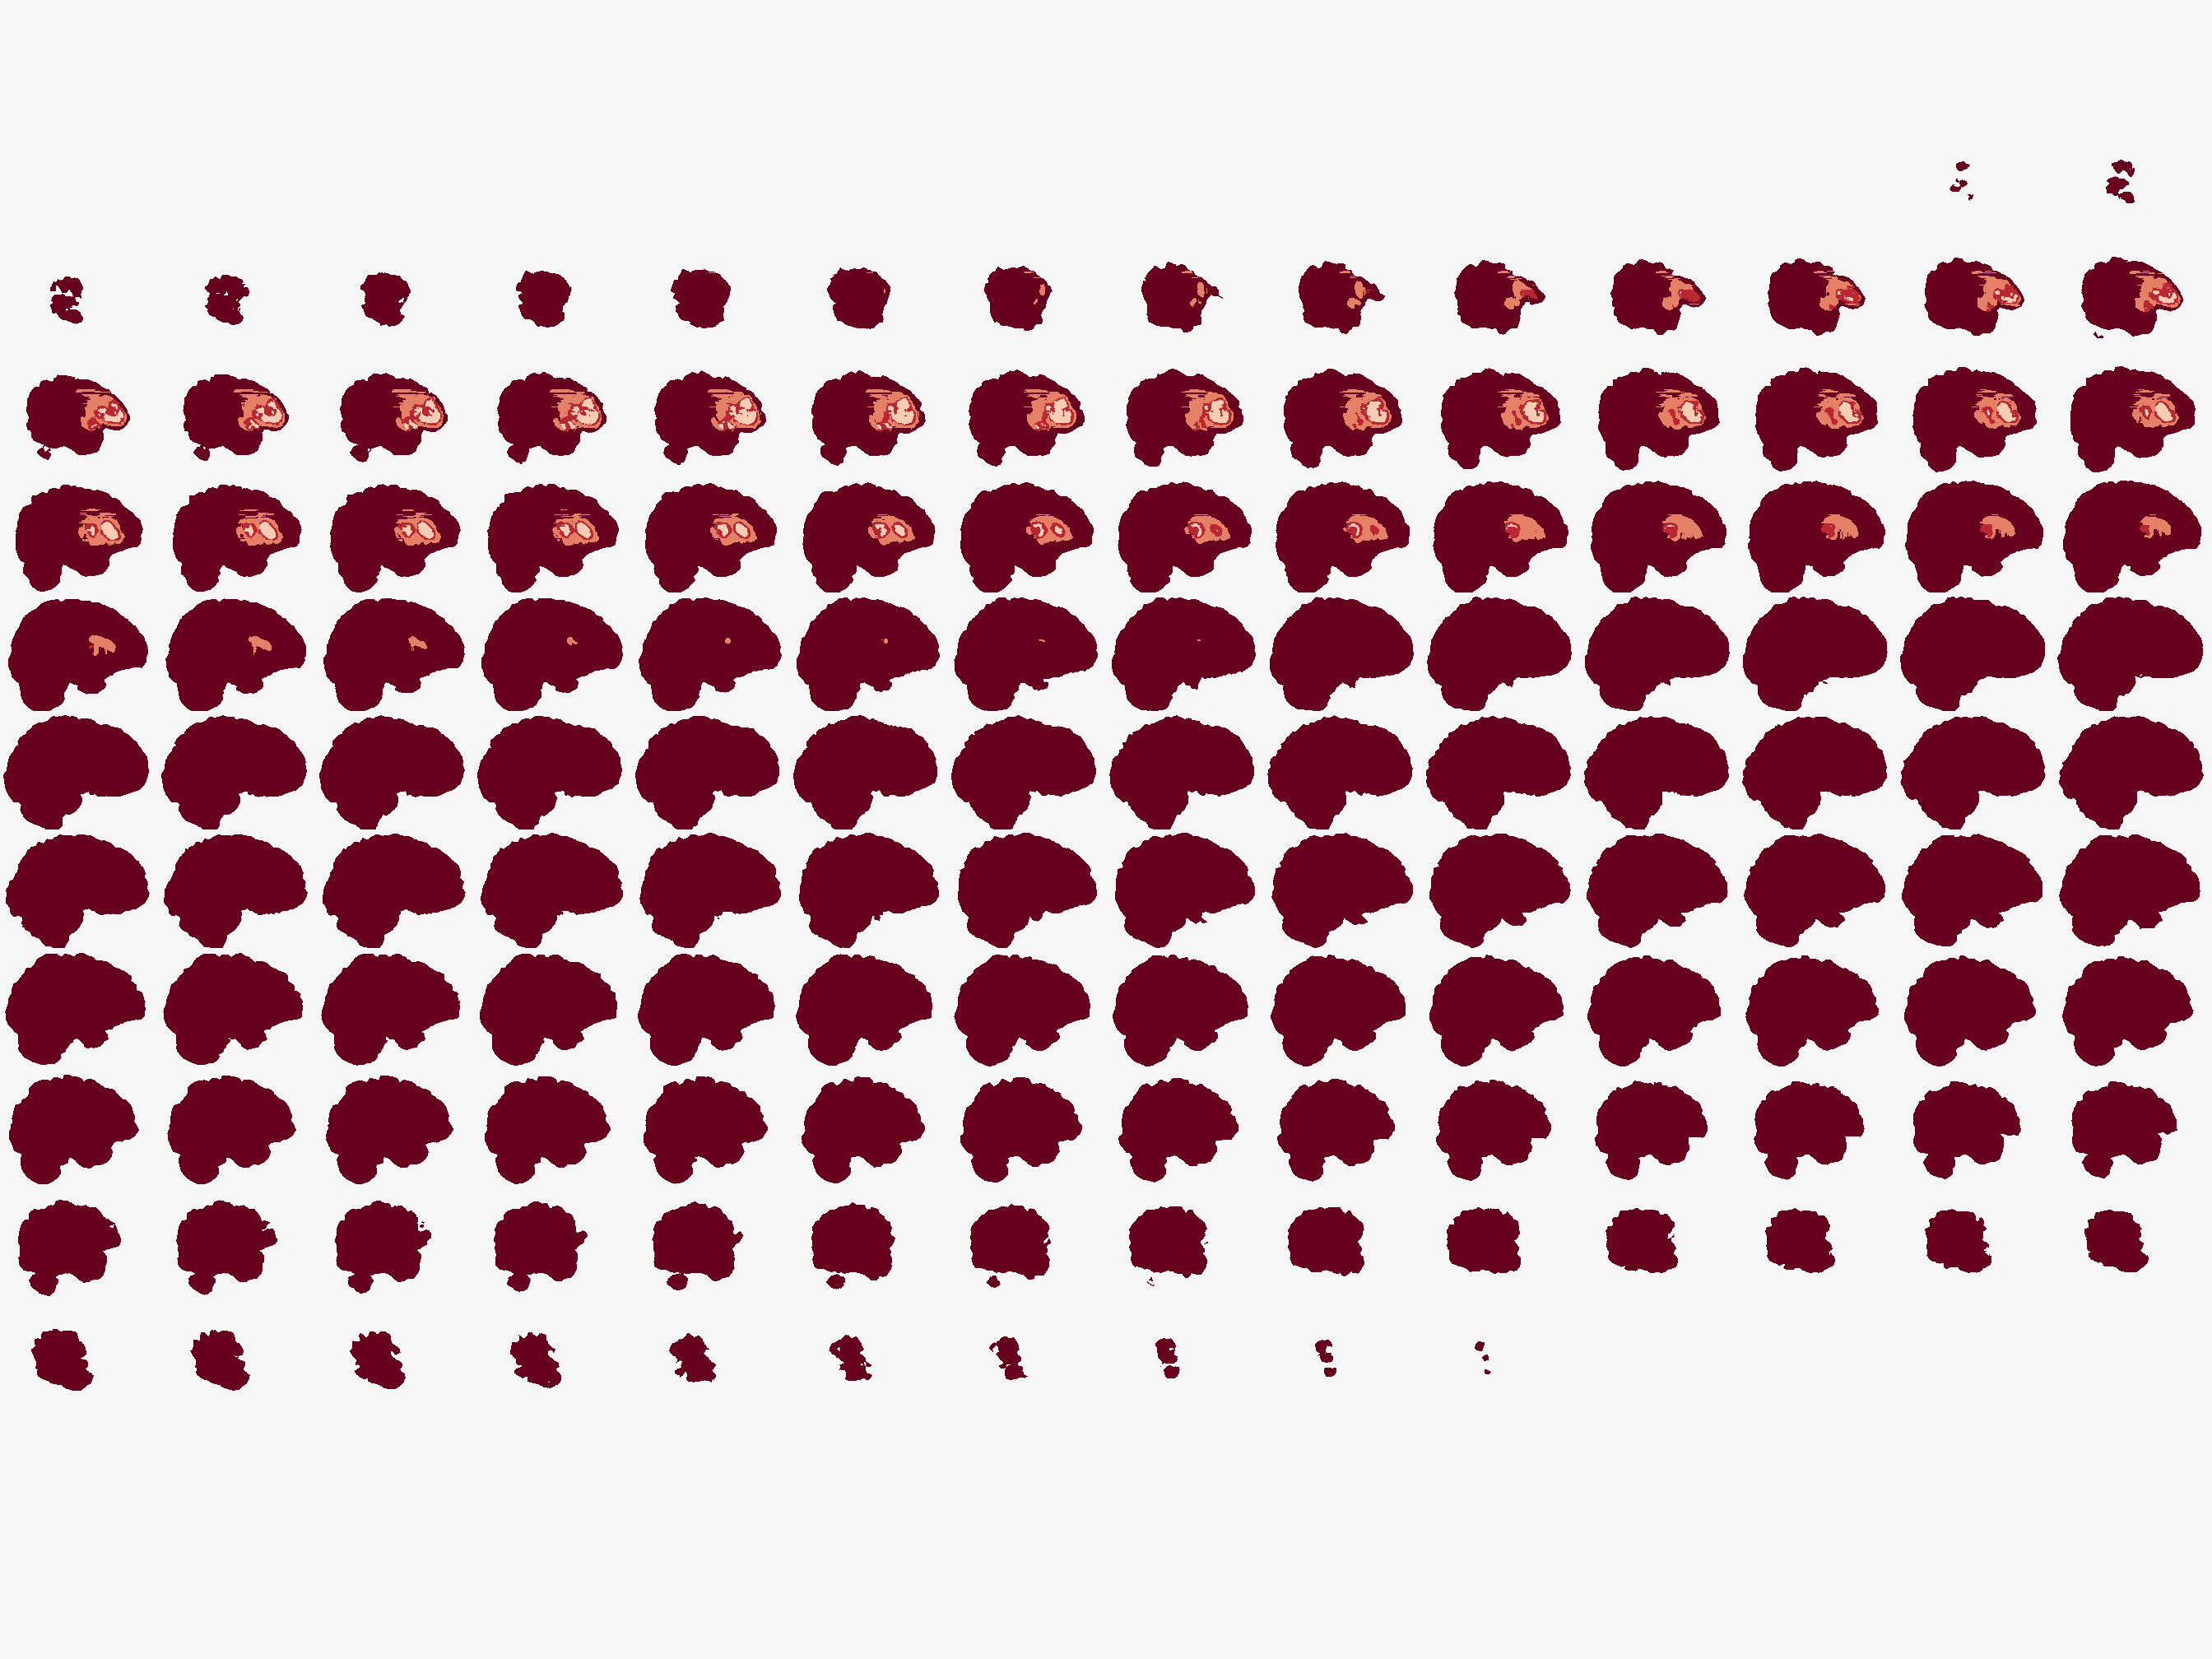

In [51]:
anat = nib.load("experiments/med-ddpm/exports/t1/1_BraTS2021_00529_t1.nii.gz")
seg  = nib.load("experiments/med-ddpm/dataset/brats2021/seg/BraTS2021_00529_seg.nii.gz")

#view = plotting.view_img(seg, bg_img=anat, cmap="autumn", threshold=0.2)
view = plotting.view_img(seg, bg_img=None, threshold=None)
view

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchio as tio
from experiments.ddpm_25d.preprocessed_dataset import PreprocessedBraTSSliceDataset

In [3]:
dataset = PreprocessedBraTSSliceDataset(Path("data/preprocessed2"), 128)

Found 1251 preprocessed volumes.
Total preprocessed slices: 385308


In [68]:
data = dataset[107]
x = data["context"].squeeze(0)

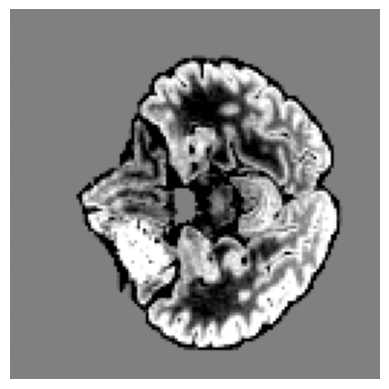

In [10]:
x_vis = (x + 1) / 2
x_vis = x_vis.cpu().numpy()

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

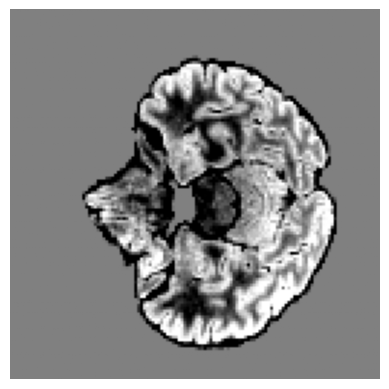

In [6]:
x = data["neighbor"].squeeze(0)
x_vis = (x + 1) / 2
x_vis = x_vis.cpu().numpy()

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

In [6]:
import torch.nn.functional as F

def intensity_normalize(
    vol: np.ndarray,
    clip_percentiles = (0.5, 99.5)
) -> np.ndarray:
    """Z-score normalize non-zero voxels of a 3D volume."""
    v = vol.copy()
    mask = v != 0

    if np.any(mask):
        vals = v#[mask]
        lo, hi = np.percentile(vals, clip_percentiles)
        vals = np.clip(vals, lo, hi)
        mean = vals.mean()
        std = vals.std() + 1e-8
        print(f"{mean=} {std=} {lo=} {hi=}")
        v = (v - mean) / std
        #v[mask] = (v[mask] - mean) / std

    return v

def preprocess_volume(volume_path: Path, output_path: Path, image_size: int, modality_suffix: str):
    """
    - Finds all *flair.nii.gz files
    - Uses central 80% slices from each volume
    - Returns normalized 2D slice as tensor in [-1, 1], shape (1, H, W)
    - Also returns normalized slice index in [0, 1]
    """
    print(f"[INFO] Processing volume: {volume_path}")

    img = nib.load(str(volume_path))
    vol = np.asanyarray(img.dataobj).astype(np.float32)  # (H, W, D)

    vol = intensity_normalize(vol)

    if vol.ndim != 3:
        print(f"[WARN] Skipping {volume_path}, not 3D (shape={vol.shape})")
        return

    slices = []
    z_pos_list = []

    for z in range(vol.shape[2]):
        crop_top = 32
        crop_left = 8
        crop_height = 168
        crop_width = 224

        slice = vol[crop_top:crop_top+crop_height, crop_left:crop_left+crop_width, z].copy()

        t = torch.from_numpy(slice[None, None].astype(np.float32))
        out = F.interpolate(t, size=image_size, mode= 'bilinear', align_corners=False)
        slice_tensor = out[0, 0]

        # z normalization:
        z_pos = np.float32(z / (vol.shape[2] - 1))

        slices.append(slice_tensor)
        z_pos_list.append(z_pos)

    if not slices:
        print(f"[WARN] No valid slices for {volume_path}")
        return

    slices = torch.stack(slices, dim=0)  # (num_slices, 1, image_size, image_size)
    z_pos = torch.tensor(z_pos_list, dtype=torch.float32)  # (num_slices,)

    #output_path.parent.mkdir(parents=True, exist_ok=True)
    #torch.save({"slices": slices, "z_pos": z_pos}, output_path)

    print(
        f"[OK] Saved {slices.shape[0]} slices for {volume_path} "
        #f"to {output_path}"
    )
    return slices


NameError: name 'np' is not defined

In [5]:
volume_path = "data/brats-2021/BraTS2021_00000/BraTS2021_00000_flair.nii.gz"
slices = preprocess_volume(volume_path, "", 128, "")

NameError: name 'preprocess_volume' is not defined

In [2]:
!pip install torchio

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 69.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 4/6 [typer]  WARNING: The script typer is installed in '/home/scc/ml8238/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [torchio]  WARNING: The scripts tiohd, tiotr and torchio-transform are installed in '/home/scc/ml8238/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [torchio]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
volume_path = "data/brats-2021/BraTS2021_00053/BraTS2021_00053_flair.nii.gz"
img = tio.ScalarImage(volume_path)

In [4]:
normalize = tio.RescaleIntensity((-1, 1))
crop = tio.CropOrPad((168,224,155))
img = normalize(crop(img))

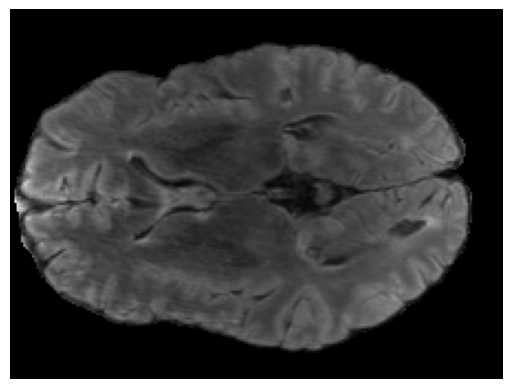

In [5]:
x = img.data.squeeze(0)[:,:,61]
x_vis = (x + 1) / 2
x_vis = x_vis.cpu().numpy()

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

In [6]:
dataset = PreprocessedBraTSSliceDataset(Path("data/preprocessed3"), 128)

Found 1251 preprocessed volumes.
Total preprocessed slices: 385308


In [13]:
data = dataset[200]
x = data["context"].squeeze(0)

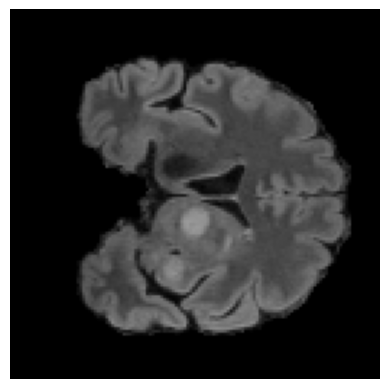

In [14]:
x_vis = (x + 1) / 2
x_vis = x_vis.cpu().numpy()

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

In [2]:
import torchio as tio

In [19]:
volume_path = "data/brats-2021/BraTS2021_00053/BraTS2021_00053_seg.nii.gz"

img = tio.ScalarImage(volume_path).data

img[img > 0] = 1


crop = tio.CropOrPad((168,224,155))
img = crop(img)
vol = img.data

In [20]:
x = vol.squeeze(0)[100]

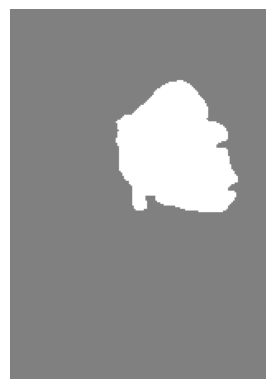

In [21]:
x_vis = (x + 1) / 2
x_vis = x_vis.cpu().numpy()

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

In [12]:
volume_path = "data/brats-2021/BraTS2021_00053/BraTS2021_00053_seg.nii.gz"

img = tio.ScalarImage(volume_path).data

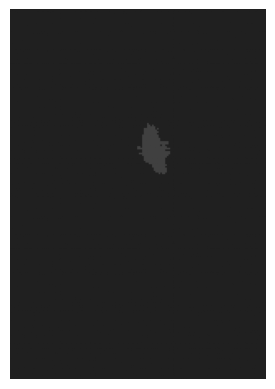

In [32]:
x = img.squeeze(0)[66]
#x_vis = (x + 1) / 2
#x_vis = x_vis.cpu().numpy()

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=4.0)
plt.axis('off')
plt.show()

In [18]:
dataset = PreprocessedBraTSSliceDataset(Path("data/preprocessed3"), 128)

Found 1251 preprocessed volumes.
Total preprocessed slices: 385308


In [34]:
img = dataset[90]["context"].squeeze(0).numpy()
th = threshold_otsu(img)
img = (img > -0.80) * 1

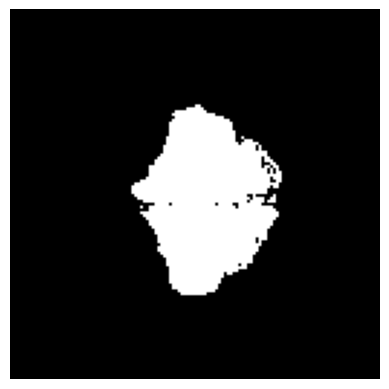

In [40]:
plt.imshow(img, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

In [41]:
i = tio.ScalarImage(volume_path)

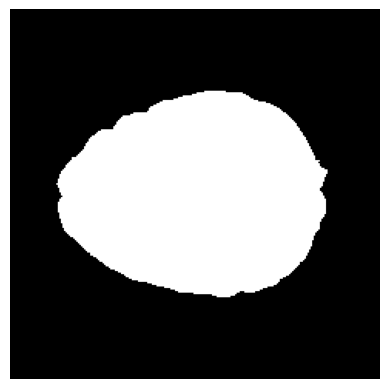

In [71]:
d = (i.data.squeeze(0)[:, :, 99] > 100) * 1
plt.imshow(d, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

In [5]:
volume_path = "data/brats-2021/BraTS2021_00000/BraTS2021_00000_flair.nii.gz"

img = tio.ScalarImage(volume_path).data
print(type(img))
img = (img > 100) * 1
print(type(img))
crop = tio.CropOrPad((168,224,155))
img = crop(img)
print(img.shape)
vol = img.data
print(vol.shape)
(vol == img.data).min()

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([1, 168, 224, 155])
torch.Size([1, 168, 224, 155])


tensor(True)

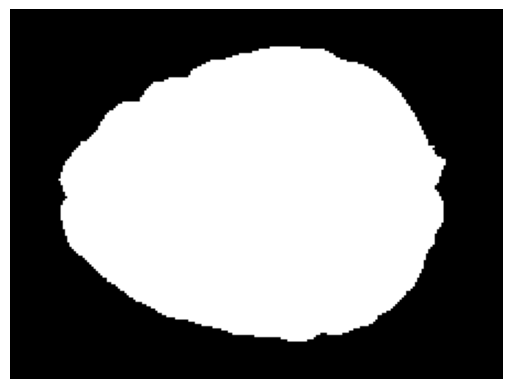

In [76]:
d = vol.data.squeeze(0)[:, :, 99]
plt.imshow(d, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

In [102]:
resample = tio.Resample((168/128, 224/128, 1))
r = resample(i)

In [103]:
r.data.shape

torch.Size([1, 182, 137, 155])

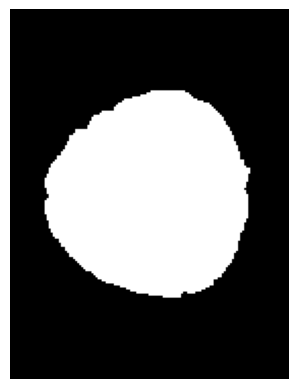

In [104]:
d = r.data.squeeze(0)[:, :, 99]
plt.imshow(d, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

In [120]:
i = tio.ScalarImage(volume_path)
pad = tio.CropOrPad((168, 224, 155))
normalize = tio.RescaleIntensity((-1, 1))
resize = tio.Resize((128, 128, 155))
i = resize(pad(normalize(i)))

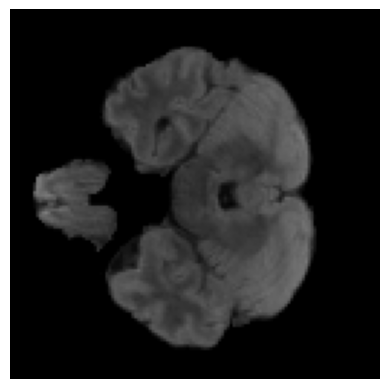

In [121]:
d = i.data.squeeze(0)[:, :, 33]
#d = d / 2 + 0.5
plt.imshow(d, cmap='gray', vmin=-1.0, vmax=1.0)
plt.axis('off')
plt.show()

In [130]:
d = i.data

In [132]:
d.permute(3, 0, 1, 2)

torch.Size([155, 1, 128, 128])

In [129]:
dataset

AttributeError: 'PreprocessedBraTSSliceDataset' object has no attribute 'shape'

In [26]:
img = tio.ScalarImage(volume_path).data
normalize = tio.RescaleIntensity((-1, 1))
crop = tio.CropOrPad((168,224,155))
resize = tio.Resize((128, 128, 155))
img = resize(normalize(crop(img)))
vol = img.data

slices = vol.permute(3, 0, 1, 2) # [1, H, W, D] -> [D, 1, H, W]
z_pos = torch.linspace(0, 1, vol.shape[3])

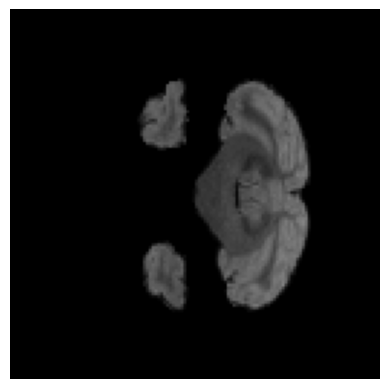

In [27]:
visualize(slices[33].squeeze(0))

In [30]:
z_pos[33] == 33 / 154

tensor(True)

In [62]:
def visualize(x, title=None, shift=True):
    if shift:
        x_vis = (x + 1) / 2
        x_vis = x_vis.cpu().numpy()
    else:
        x_vis = x
    plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
    if title is not None:
        plt.title(title, fontsize=8)
    plt.axis('off')
    plt.show()

In [37]:
img = tio.ScalarImage(volume_path).data
img = (img > 10) * 1
crop = tio.CropOrPad((168,224,155))
resize = tio.Resize((128, 128, 155))
img = resize(crop(img))
vol = img.data

slices = vol.permute(3, 0, 1, 2) # [1, H, W, D] -> [D, 1, H, W]
z_pos = torch.linspace(0, 1, vol.shape[3])

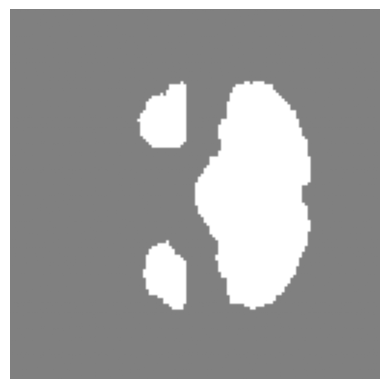

In [39]:
visualize(slices[33].squeeze(0))

In [45]:
dataset = PreprocessedBraTSSliceDataset(Path("data/preprocessed_masks"), 128)

Found 1251 preprocessed volumes.
Total preprocessed slices: 385308


In [70]:
data = dataset[92]["context"].squeeze(0)

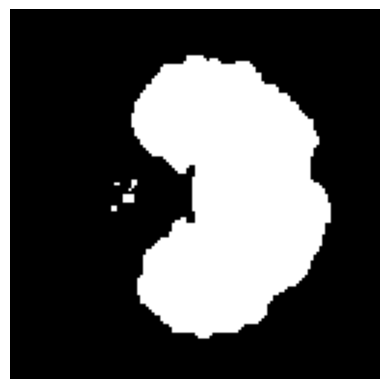

In [71]:
visualize(data, shift=False)